# Week 3 – Product & Inventory Exploratory Data Analysis

## Objective

The purpose of this notebook is to analyse product performance and inventory conditions using the validated and feature-engineered datasets produced during Weeks 2 and 3.

The analysis focuses on:

- Product sales performance
- Product quantity sold
- Fast-moving products
- Slow-moving products
- Current inventory levels
- Reorder levels
- Safety stock
- Maximum stock capacity
- Stock utilisation
- Potential stockout and replenishment risks
- Inventory performance by branch
- Products with high sales and low stock

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [2]:
sales = pd.read_csv(
    "/content/sales_features.csv"
)

inventory = pd.read_csv(
    "/content/inventory_master.csv"
)

products = pd.read_csv(
    "/content/products.csv"
)

print("Sales:", sales.shape)
print("Inventory:", inventory.shape)
print("Products:", products.shape)

Sales: (130402, 83)
Inventory: (180, 8)
Products: (30, 23)


Inspect Columns

In [18]:
print("Sales columns:")
print(sales.columns.tolist())

print("Inventory columns:")
print(inventory.columns.tolist())

print("\nProduct columns:")
print(products.columns.tolist())

Sales columns:
['so_id', 'line_number', 'product_id', 'quantity', 'unit_price', 'gst_rate', 'line_total', 'gst_amount', 'line_grand_total', 'customer_id', 'branch_id', 'order_date', 'delivery_date', 'order_status', 'payment_terms', 'total_order_value', 'total_gst_amount', 'grand_total', 'sales_channel', 'product_name', 'category', 'machine_type', 'brand', 'model_compatibility', 'unit_cost', 'unit_price_product', 'margin_percentage', 'gst_rate_product', 'weight_kg', 'dimensions_cm', 'material_type', 'warranty_months', 'reorder_level', 'safety_stock', 'max_stock_level', 'lead_time_days', 'criticality_level', 'usage_frequency', 'uom', 'last_purchase_price', 'last_purchase_date', 'customer_type', 'industry_segment', 'city', 'state', 'pincode', 'region', 'branch_id_customer', 'credit_limit', 'current_balance', 'payment_terms_customer', 'customer_since', 'last_purchase_date_customer', 'total_purchase_value', 'customer_rating', 'order_year', 'order_month', 'order_month_name', 'order_quarter',

Inventory Information

In [4]:
print("Inventory shape:", inventory.shape)

inventory.info()

print("\nMissing values:")
display(
    inventory.isnull()
    .sum()
    .sort_values(ascending=False)
)

Inventory shape: (180, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     180 non-null    object
 1   branch_id      180 non-null    object
 2   opening_stock  180 non-null    int64 
 3   reorder_level  180 non-null    int64 
 4   safety_stock   180 non-null    int64 
 5   max_stock      180 non-null    int64 
 6   current_stock  180 non-null    int64 
 7   warehouse_bin  180 non-null    object
dtypes: int64(5), object(3)
memory usage: 11.4+ KB

Missing values:


,0
product_id,0
branch_id,0
opening_stock,0
reorder_level,0
safety_stock,0
max_stock,0
current_stock,0
warehouse_bin,0


Product Information

In [5]:
print("Products shape:", products.shape)

products.info()

print("\nMissing values:")
display(
    products.isnull()
    .sum()
    .sort_values(ascending=False)
)

Products shape: (30, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   product_id           30 non-null     object 
 1   product_name         30 non-null     object 
 2   category             30 non-null     object 
 3   machine_type         30 non-null     object 
 4   brand                30 non-null     object 
 5   model_compatibility  30 non-null     object 
 6   unit_cost            30 non-null     int64  
 7   unit_price           30 non-null     int64  
 8   margin_percentage    30 non-null     float64
 9   gst_rate             30 non-null     int64  
 10  weight_kg            30 non-null     float64
 11  dimensions_cm        30 non-null     object 
 12  material_type        30 non-null     object 
 13  warranty_months      30 non-null     int64  
 14  reorder_level        30 non-null     int64  
 15  safety_stock     

,0
product_id,0
product_name,0
category,0
machine_type,0
brand,0
model_compatibility,0
unit_cost,0
unit_price,0
margin_percentage,0
gst_rate,0


Inventory Descriptive Statistics

In [19]:
inventory_numeric = [
    'opening_stock',
    'reorder_level',
    'safety_stock',
    'max_stock',
    'current_stock'
]

display(
    inventory[inventory_numeric].describe()
)

,opening_stock,reorder_level,safety_stock,max_stock,current_stock
count,180.000000,180.0000,180.000000,180.000000,180.000000
mean,183.161111,64.5500,45.205556,321.755556,107240.366667
std,63.441009,24.0554,16.873402,116.554283,5341.085645
min,80.000000,24.0000,16.000000,131.000000,88853.000000
25%,129.000000,44.0000,31.000000,230.000000,103487.500000
50%,178.500000,62.0000,43.500000,310.500000,107790.500000
75%,234.500000,82.2500,58.000000,415.500000,110779.500000
max,300.000000,119.0000,85.000000,582.000000,121013.000000


Total Stock Measures

In [20]:
print("=" * 60)
print("INVENTORY SUMMARY")
print("=" * 60)

print(
    "Total Opening Stock:",
    f"{inventory['opening_stock'].sum():,.0f}"
)

print(
    "Total Current Stock:",
    f"{inventory['current_stock'].sum():,.0f}"
)

print(
    "Total Reorder Level:",
    f"{inventory['reorder_level'].sum():,.0f}"
)

print(
    "Total Safety Stock:",
    f"{inventory['safety_stock'].sum():,.0f}"
)

print(
    "Total Maximum Stock Capacity:",
    f"{inventory['max_stock'].sum():,.0f}"
)

INVENTORY SUMMARY
Total Opening Stock: 32,969
Total Current Stock: 19,303,266
Total Reorder Level: 11,619
Total Safety Stock: 8,137
Total Maximum Stock Capacity: 57,916


Create Stock Status

In [21]:
inventory['stock_status'] = np.select(
    [
        inventory['current_stock'] <= 0,

        (
            inventory['current_stock']
            < inventory['reorder_level']
        ),

        (
            inventory['current_stock']
            < inventory['safety_stock']
        ),

        (
            inventory['current_stock']
            > inventory['max_stock']
        )
    ],
    [
        'Out of Stock',
        'Below Reorder Level',
        'Below Safety Stock',
        'Above Maximum Stock'
    ],
    default='Healthy'
)

display(
    inventory[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock',
            'stock_status'
        ]
    ].head(10)
)

,product_id,branch_id,current_stock,reorder_level,safety_stock,max_stock,stock_status
0,P001,DEL001,115928,59,46,340,Above Maximum Stock
1,P001,PUN001,109389,70,43,349,Above Maximum Stock
2,P001,CHN001,99373,62,44,311,Above Maximum Stock
3,P001,HYD001,108772,71,65,417,Above Maximum Stock
4,P001,KOL001,103808,94,58,475,Above Maximum Stock
5,P001,AHM001,106714,77,53,455,Above Maximum Stock
6,P002,DEL001,108628,57,35,261,Above Maximum Stock
7,P002,PUN001,101623,41,27,180,Above Maximum Stock
8,P002,CHN001,105885,102,76,465,Above Maximum Stock
9,P002,HYD001,121013,78,64,383,Above Maximum Stock


Stock Status Summary

In [22]:
stock_status_summary = (
    inventory['stock_status']
    .value_counts()
    .reset_index()
)

stock_status_summary.columns = [
    'stock_status',
    'inventory_records'
]

display(stock_status_summary)

,stock_status,inventory_records
0,Above Maximum Stock,180


Stock Status Chart

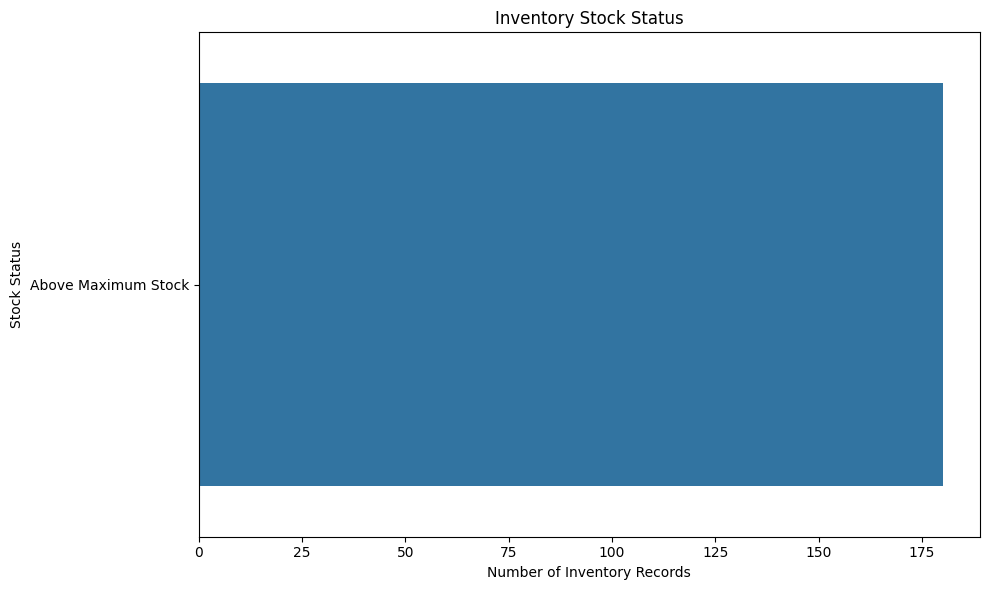

In [23]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=stock_status_summary,
    x='inventory_records',
    y='stock_status'
)

plt.title("Inventory Stock Status")
plt.xlabel("Number of Inventory Records")
plt.ylabel("Stock Status")

plt.tight_layout()
plt.show()

Out-of_Stock Analysis

In [24]:
out_of_stock = inventory[
    inventory['current_stock'] <= 0
].copy()

print(
    "Out-of-stock inventory records:",
    len(out_of_stock)
)

display(
    out_of_stock[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock',
            'warehouse_bin'
        ]
    ].head(20)
)

Out-of-stock inventory records: 0


,product_id,branch_id,current_stock,reorder_level,safety_stock,max_stock,warehouse_bin


Products below Recorder Level

In [25]:
below_reorder = inventory[
    inventory['current_stock']
    < inventory['reorder_level']
].copy()

print(
    "Records below reorder level:",
    len(below_reorder)
)

display(
    below_reorder[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock',
            'warehouse_bin'
        ]
    ].head(20)
)

Records below reorder level: 0


,product_id,branch_id,current_stock,reorder_level,safety_stock,max_stock,warehouse_bin


Products below Safety Stock

In [26]:
below_safety = inventory[
    inventory['current_stock']
    < inventory['safety_stock']
].copy()

print(
    "Records below safety stock:",
    len(below_safety)
)

display(
    below_safety[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock',
            'warehouse_bin'
        ]
    ].head(20)
)

Records below safety stock: 0


,product_id,branch_id,current_stock,reorder_level,safety_stock,max_stock,warehouse_bin


Stock Utilisation

In [27]:
# Because the dataset has max_stock, we can calculate how much of the available stock capacity is currently being used.

inventory['stock_utilisation_pct'] = np.where(
    inventory['max_stock'] > 0,
    (
        inventory['current_stock']
        / inventory['max_stock']
    ) * 100,
    np.nan
)

display(
    inventory[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'max_stock',
            'stock_utilisation_pct'
        ]
    ].head(10)
)

,product_id,branch_id,current_stock,max_stock,stock_utilisation_pct
0,P001,DEL001,115928,340,34096.470588
1,P001,PUN001,109389,349,31343.553009
2,P001,CHN001,99373,311,31952.733119
3,P001,HYD001,108772,417,26084.412470
4,P001,KOL001,103808,475,21854.315789
5,P001,AHM001,106714,455,23453.626374
6,P002,DEL001,108628,261,41619.923372
7,P002,PUN001,101623,180,56457.222222
8,P002,CHN001,105885,465,22770.967742
9,P002,HYD001,121013,383,31596.083551


Reorder Gap

In [28]:
# Calculate how many additional units are required to reach the reorder level.
inventory['reorder_gap'] = (
    inventory['reorder_level']
    - inventory['current_stock']
)

inventory['reorder_gap'] = (
    inventory['reorder_gap']
    .clip(lower=0)
)

display(
    inventory[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'reorder_level',
            'reorder_gap'
        ]
    ]
    .sort_values(
        'reorder_gap',
        ascending=False
    )
    .head(20)
)

,product_id,branch_id,current_stock,reorder_level,reorder_gap
0,P001,DEL001,115928,59,0
1,P001,PUN001,109389,70,0
2,P001,CHN001,99373,62,0
3,P001,HYD001,108772,71,0
4,P001,KOL001,103808,94,0
5,P001,AHM001,106714,77,0
6,P002,DEL001,108628,57,0
7,P002,PUN001,101623,41,0
8,P002,CHN001,105885,102,0
9,P002,HYD001,121013,78,0


Top Products by Current Stock

In [29]:
top_stock = (
    inventory
    .sort_values(
        'current_stock',
        ascending=False
    )
    .head(10)
)

display(
    top_stock[
        [
            'product_id',
            'branch_id',
            'current_stock',
            'max_stock',
            'warehouse_bin'
        ]
    ]
)

,product_id,branch_id,current_stock,max_stock,warehouse_bin
9,P002,HYD001,121013,383,A02
66,P012,DEL001,119923,489,D13
36,P007,DEL001,119439,383,C04
108,P019,DEL001,118200,208,D07
13,P003,PUN001,118139,359,F09
99,P017,HYD001,117058,172,F05
138,P024,DEL001,116412,469,A17
0,P001,DEL001,115928,340,C15
120,P021,DEL001,115902,257,F08
59,P010,AHM001,115149,245,C09


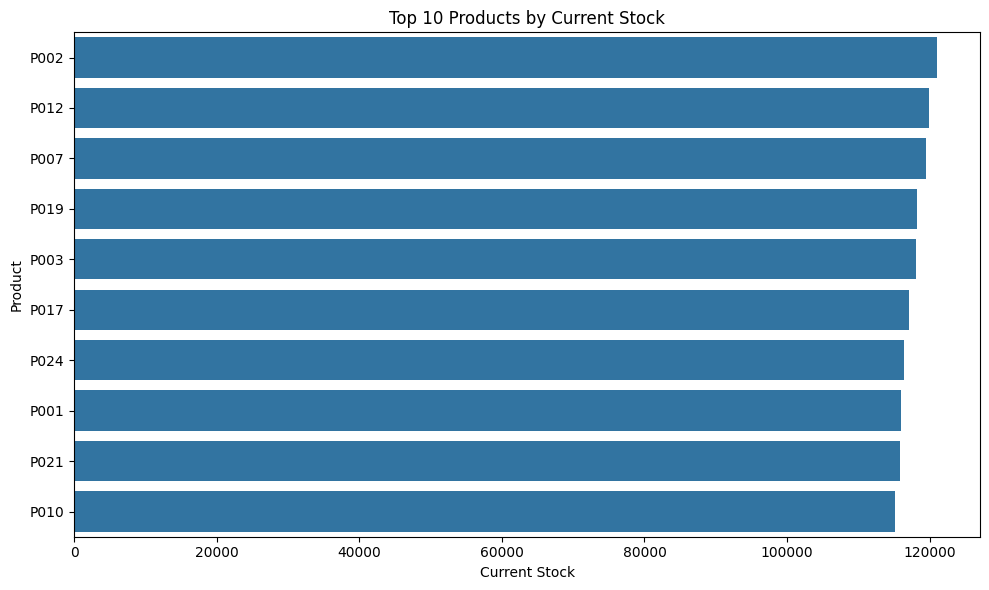

In [30]:
# Chart

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_stock,
    x='current_stock',
    y='product_id'
)

plt.title("Top 10 Products by Current Stock")
plt.xlabel("Current Stock")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Inventory by Branch

In [31]:
branch_inventory = (
    inventory
    .groupby('branch_id')
    .agg(
        total_current_stock=(
            'current_stock',
            'sum'
        ),
        total_reorder_level=(
            'reorder_level',
            'sum'
        ),
        total_safety_stock=(
            'safety_stock',
            'sum'
        ),
        total_max_stock=(
            'max_stock',
            'sum'
        ),
        inventory_records=(
            'product_id',
            'count'
        )
    )
    .reset_index()
)

display(branch_inventory)

,branch_id,total_current_stock,total_reorder_level,total_safety_stock,total_max_stock,inventory_records
0,AHM001,3154992,1915,1319,9690,30
1,CHN001,3234245,1952,1353,9642,30
2,DEL001,3288670,1968,1379,9744,30
3,HYD001,3245291,1928,1428,9437,30
4,KOL001,3123805,2174,1498,10846,30
5,PUN001,3256263,1682,1160,8557,30


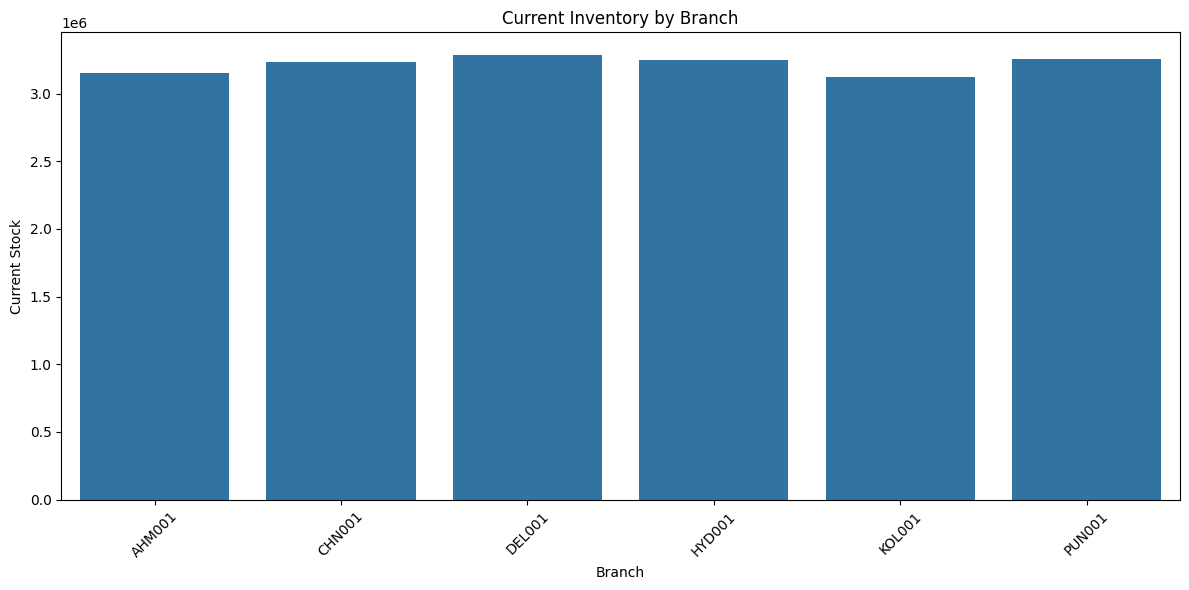

In [32]:
# Branch Inventory Chart
plt.figure(figsize=(12, 6))

sns.barplot(
    data=branch_inventory,
    x='branch_id',
    y='total_current_stock'
)

plt.title("Current Inventory by Branch")
plt.xlabel("Branch")
plt.ylabel("Current Stock")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Product Sales Performance

In [33]:
product_sales = (
    sales
    .groupby('product_id')
    .agg(
        total_sales=(
            'line_grand_total',
            'sum'
        ),
        total_quantity_sold=(
            'quantity',
            'sum'
        ),
        total_orders=(
            'so_id',
            'nunique'
        ),
        total_customers=(
            'customer_id',
            'nunique'
        )
    )
    .reset_index()
)

display(
    product_sales.head(10)
)

,product_id,total_sales,total_quantity_sold,total_orders,total_customers
0,P001,1.423399e+09,45389,3854,500
1,P002,3.852256e+07,45342,3861,500
2,P003,6.738390e+07,45684,3895,500
3,P004,2.321773e+09,45575,3781,500
4,P005,4.870012e+08,45026,3840,500
5,P006,6.699356e+08,46731,3936,500
6,P007,7.950675e+07,46468,3906,499
7,P008,3.105533e+07,45376,3860,500
8,P009,8.572101e+08,44946,3784,499
9,P010,2.097976e+09,46964,3933,500


Top Products by Sales

In [34]:
top_revenue_products = (
    product_sales
    .sort_values(
        'total_sales',
        ascending=False
    )
)

display(
    top_revenue_products.head(10)
)

,product_id,total_sales,total_quantity_sold,total_orders,total_customers
14,P015,6.888215e+09,45222,3773,499
13,P014,4.813341e+09,45035,3838,500
20,P021,2.741782e+09,46364,3873,500
18,P019,2.341947e+09,45971,3849,499
3,P004,2.321773e+09,45575,3781,500
9,P010,2.097976e+09,46964,3933,500
10,P011,1.646709e+09,46612,3982,500
0,P001,1.423399e+09,45389,3854,500
29,P030,1.286585e+09,45897,3856,500
21,P022,9.911566e+08,45819,3892,500


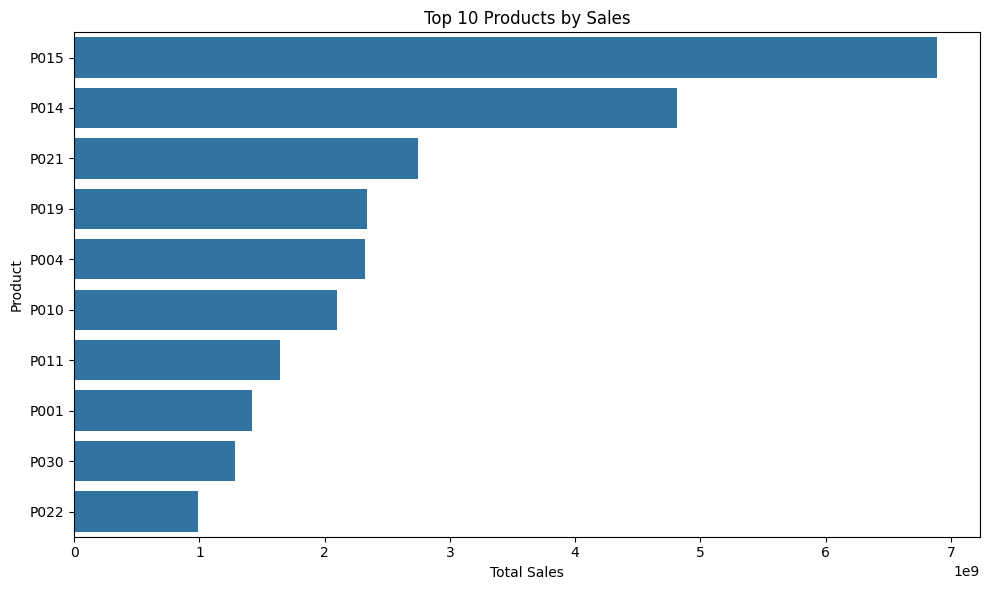

In [35]:
# Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_revenue_products.head(10),
    x='total_sales',
    y='product_id'
)

plt.title("Top 10 Products by Sales")
plt.xlabel("Total Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Fast-Moving Products

In [36]:
fast_moving = (
    product_sales
    .sort_values(
        'total_quantity_sold',
        ascending=False
    )
)

display(
    fast_moving.head(10)
)

,product_id,total_sales,total_quantity_sold,total_orders,total_customers
28,P029,2.193746e+08,47066,3882,500
9,P010,2.097976e+09,46964,3933,500
5,P006,6.699356e+08,46731,3936,500
10,P011,1.646709e+09,46612,3982,500
6,P007,7.950675e+07,46468,3906,499
20,P021,2.741782e+09,46364,3873,500
15,P016,5.573390e+08,46306,3934,500
27,P028,1.225654e+08,46164,3917,500
11,P012,1.441682e+08,45972,3883,500
18,P019,2.341947e+09,45971,3849,499


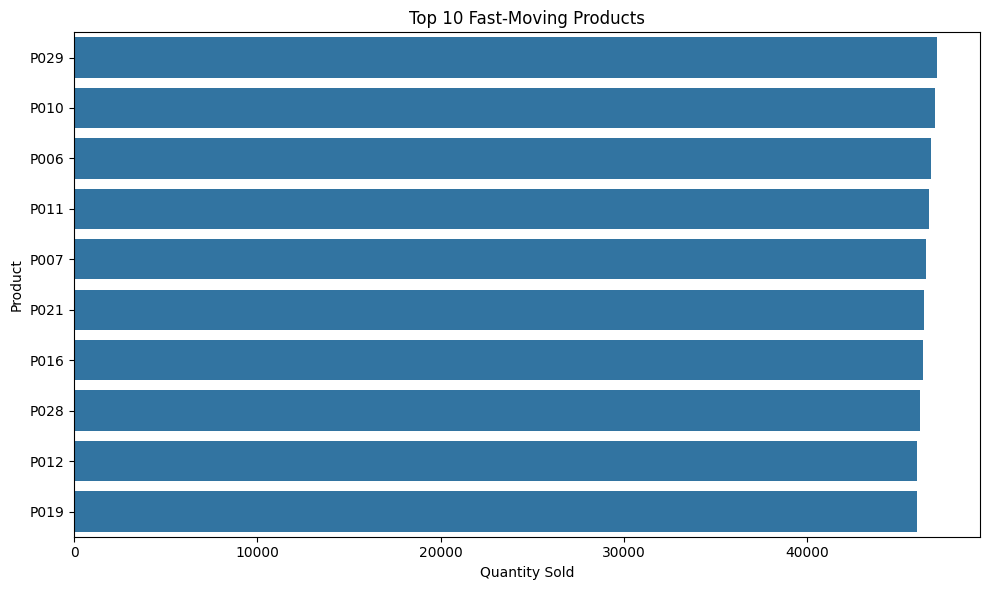

In [37]:
# Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=fast_moving.head(10),
    x='total_quantity_sold',
    y='product_id'
)

plt.title("Top 10 Fast-Moving Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

Slow-Moving Products

In [38]:
slow_moving = (
    product_sales
    .sort_values(
        'total_quantity_sold',
        ascending=True
    )
)

display(
    slow_moving.head(10)
)

,product_id,total_sales,total_quantity_sold,total_orders,total_customers
23,P024,5.803860e+08,44022,3762,500
12,P013,7.542259e+07,44081,3783,499
22,P023,7.365877e+08,44437,3754,500
25,P026,1.640394e+07,44844,3823,500
8,P009,8.572101e+08,44946,3784,499
4,P005,4.870012e+08,45026,3840,500
17,P018,6.512705e+08,45027,3839,500
13,P014,4.813341e+09,45035,3838,500
14,P015,6.888215e+09,45222,3773,499
19,P020,6.152638e+07,45340,3823,500


Merge Sales and Inventory

In [39]:
product_inventory = product_sales.merge(
    inventory,
    on='product_id',
    how='left',
    suffixes=(
        '_sales',
        '_inventory'
    )
)

print(
    "Product + Inventory shape:",
    product_inventory.shape
)

display(
    product_inventory.head()
)

Product + Inventory shape: (180, 15)


,product_id,total_sales,total_quantity_sold,total_orders,total_customers,branch_id,opening_stock,reorder_level,safety_stock,max_stock,current_stock,warehouse_bin,stock_status,stock_utilisation_pct,reorder_gap
0,P001,1.423399e+09,45389,3854,500,DEL001,196,59,46,340,115928,C15,Above Maximum Stock,34096.470588,0
1,P001,1.423399e+09,45389,3854,500,PUN001,198,70,43,349,109389,D16,Above Maximum Stock,31343.553009,0
2,P001,1.423399e+09,45389,3854,500,CHN001,187,62,44,311,99373,A11,Above Maximum Stock,31952.733119,0
3,P001,1.423399e+09,45389,3854,500,HYD001,226,71,65,417,108772,A10,Above Maximum Stock,26084.412470,0
4,P001,1.423399e+09,45389,3854,500,KOL001,263,94,58,475,103808,F03,Above Maximum Stock,21854.315789,0


Check Product-Inventory Matching

In [40]:
print(
    "Products in sales:",
    product_sales['product_id'].nunique()
)

print(
    "Products in inventory:",
    inventory['product_id'].nunique()
)

print(
    "Products matched:",
    product_inventory['current_stock']
    .notna()
    .sum()
)

print(
    "Products without inventory match:",
    product_inventory['current_stock']
    .isna()
    .sum()
)

Products in sales: 30
Products in inventory: 30
Products matched: 180
Products without inventory match: 0


High Sales / Low-Stock Products

In [44]:
sales_threshold = (
    product_inventory[
        'total_quantity_sold'
    ].quantile(0.75)
)

high_sales_low_stock = product_inventory[
    (
        product_inventory['current_stock']
        <
        product_inventory['reorder_level']
    )
    &
    (
        product_inventory['total_quantity_sold']
        >= sales_threshold
    )
].copy()

print(
    "High-sales / low-stock products:",
    len(high_sales_low_stock)
)

display(
    high_sales_low_stock[
        [
            'product_id',
            'total_sales',
            'total_quantity_sold',
            'total_orders',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock',
            'stock_status'
        ]
    ]
    .sort_values(
        'total_sales',
        ascending=False
    )
    .head(20)
)

High-sales / low-stock products: 0


,product_id,total_sales,total_quantity_sold,total_orders,current_stock,reorder_level,safety_stock,max_stock,stock_status


High Stock / Low Sales Product

In [45]:
sales_low_threshold = (
    product_inventory[
        'total_quantity_sold'
    ].quantile(0.25)
)

high_stock_low_sales = product_inventory[
    (
        product_inventory['current_stock']
        > product_inventory['safety_stock']
    )
    &
    (
        product_inventory['total_quantity_sold']
        <= sales_low_threshold
    )
].copy()

print(
    "High-stock / low-sales products:",
    len(high_stock_low_sales)
)

display(
    high_stock_low_sales[
        [
            'product_id',
            'total_sales',
            'total_quantity_sold',
            'current_stock',
            'reorder_level',
            'safety_stock',
            'max_stock'
        ]
    ]
    .sort_values(
        'current_stock',
        ascending=False
    )
    .head(20)
)

High-stock / low-sales products: 48


,product_id,total_sales,total_quantity_sold,current_stock,reorder_level,safety_stock,max_stock
138,P024,5.803860e+08,44022,116412,99,56,469
102,P018,6.512705e+08,45027,114627,106,74,508
137,P023,7.365877e+08,44437,114558,90,50,434
80,P014,4.813341e+09,45035,114302,60,40,303
26,P005,4.870012e+08,45026,114267,68,40,336
132,P023,7.365877e+08,44437,113718,73,49,313
79,P014,4.813341e+09,45035,113386,33,20,164
104,P018,6.512705e+08,45027,113318,98,74,564
105,P018,6.512705e+08,45027,112953,78,58,322
27,P005,4.870012e+08,45026,112865,62,51,341


Current Stock vs Sales

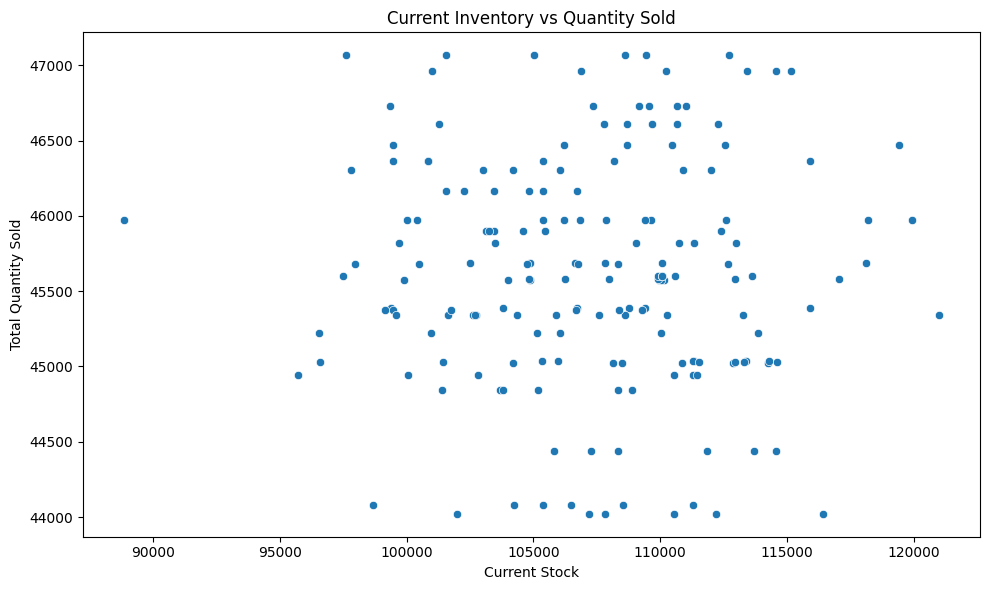

In [46]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=product_inventory,
    x='current_stock',
    y='total_quantity_sold'
)

plt.title(
    "Current Inventory vs Quantity Sold"
)

plt.xlabel("Current Stock")
plt.ylabel("Total Quantity Sold")

plt.tight_layout()
plt.show()

Stock Utilisation Distribution

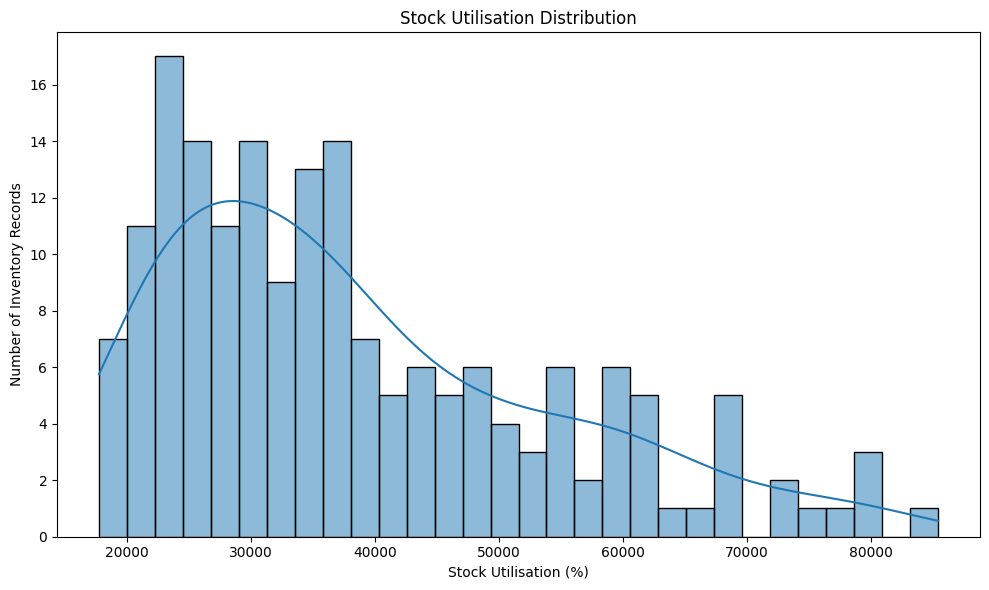

In [47]:
plt.figure(figsize=(10, 6))

sns.histplot(
    inventory['stock_utilisation_pct'].dropna(),
    bins=30,
    kde=True
)

plt.title("Stock Utilisation Distribution")
plt.xlabel("Stock Utilisation (%)")
plt.ylabel("Number of Inventory Records")

plt.tight_layout()
plt.show()

Warehouse Bin Analysis

In [49]:
warehouse_bin_summary = (
    inventory
    .groupby('warehouse_bin')
    .agg(
        inventory_records=(
            'product_id',
            'count'
        ),
        current_stock=(
            'current_stock',
            'sum'
        )
    )
    .sort_values(
        'current_stock',
        ascending=False
    )
    .reset_index()
)

display(
    warehouse_bin_summary.head(20)
)

,warehouse_bin,inventory_records,current_stock
0,E17,5,542179
1,F08,5,527039
2,A15,4,430021
3,B09,4,422824
4,C04,3,335602
5,A02,3,334263
6,A10,3,328630
7,F19,3,328008
8,B06,3,326181
9,D12,3,325629


Product Analysis Summary

In [50]:
print("=" * 60)
print("PRODUCT & INVENTORY EDA SUMMARY")
print("=" * 60)

print(
    "\nNumber of Products in Sales:",
    sales['product_id'].nunique()
)

print(
    "Number of Products in Inventory:",
    inventory['product_id'].nunique()
)

print(
    "Total Quantity Sold:",
    f"{sales['quantity'].sum():,.0f}"
)

print(
    "Total Current Stock:",
    f"{inventory['current_stock'].sum():,.0f}"
)

print(
    "Products Below Reorder Level:",
    len(below_reorder)
)

print(
    "Products Below Safety Stock:",
    len(below_safety)
)

print(
    "Out-of-Stock Records:",
    len(out_of_stock)
)

print(
    "\nTop 5 Products by Sales:"
)

display(
    top_revenue_products.head(5)
)

print(
    "\nTop 5 Fast-Moving Products:"
)

display(
    fast_moving.head(5)
)

PRODUCT & INVENTORY EDA SUMMARY

Number of Products in Sales: 30
Number of Products in Inventory: 30
Total Quantity Sold: 1,368,534
Total Current Stock: 19,303,266
Products Below Reorder Level: 0
Products Below Safety Stock: 0
Out-of-Stock Records: 0

Top 5 Products by Sales:


,product_id,total_sales,total_quantity_sold,total_orders,total_customers
14,P015,6.888215e+09,45222,3773,499
13,P014,4.813341e+09,45035,3838,500
20,P021,2.741782e+09,46364,3873,500
18,P019,2.341947e+09,45971,3849,499
3,P004,2.321773e+09,45575,3781,500



Top 5 Fast-Moving Products:


,product_id,total_sales,total_quantity_sold,total_orders,total_customers
28,P029,2.193746e+08,47066,3882,500
9,P010,2.097976e+09,46964,3933,500
5,P006,6.699356e+08,46731,3936,500
10,P011,1.646709e+09,46612,3982,500
6,P007,7.950675e+07,46468,3906,499


Business Risk Summary

In [51]:
print("=" * 60)
print("INVENTORY BUSINESS RISK SUMMARY")
print("=" * 60)

print(
    f"Out of Stock: {len(out_of_stock):,}"
)

print(
    f"Below Reorder Level: {len(below_reorder):,}"
)

print(
    f"Below Safety Stock: {len(below_safety):,}"
)

print(
    f"High Sales + Low Stock: "
    f"{len(high_sales_low_stock):,}"
)

print(
    f"High Stock + Low Sales: "
    f"{len(high_stock_low_sales):,}"
)

INVENTORY BUSINESS RISK SUMMARY
Out of Stock: 0
Below Reorder Level: 0
Below Safety Stock: 0
High Sales + Low Stock: 0
High Stock + Low Sales: 48


## **Final Notebook Status**

## Week 3 – Product & Inventory EDA Outcome

The Product and Inventory exploratory analysis examined product sales performance and current inventory conditions.

The analysis included:

- Product sales performance
- Fast- and slow-moving products
- Current stock levels
- Reorder-level analysis
- Safety-stock analysis
- Stock utilisation
- Reorder gaps
- Branch-level inventory
- Warehouse-bin analysis
- High-sales / low-stock products
- High-stock / low-sales products

The resulting analysis outputs have been saved in the `analysis/` directory and will support KPI development and future inventory and warehouse analytics.

**Status:** Completed